# Subclinical Cardiovascular Risk Detection (Gulliver Syndrome Framework)

This project explores how individuals with borderline clinical markers (blood pressure, cholesterol, BMI) may still carry significant cardiovascular risk.

Inspired by the "Gulliver Syndrome" concept, we construct a composite risk score and evaluate its predictive value using a real-world dataset.

## Objectives
- Perform exploratory data analysis (EDA)
- Engineer a composite risk score
- Use SQL for data querying
- Build a predictive model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import sqlite3

In [2]:
import os
os.getcwd()

'/Users/franvalenzuelam/Desktop'

In [3]:
df = pd.read_csv("cardio_train.csv", sep=";")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [35]:
# Convert age from days to years
df['age_years'] = df['age'] / 365

# Remove impossible BP
df = df[(df['ap_hi'] > 50) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 150)]
df = df[df['ap_hi'] > df['ap_lo']]

# Remove extreme BMI
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]

# Remove NaNs / inf
import numpy as np
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,cardio,age_years,bmi,gulliver_bp,gulliver_chol,gulliver_bmi,gulliver_score,bp_score,bmi_score,chol_score
count,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,...,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000,68598.000000
mean,49976.704423,19464.358669,1.348669,164.410187,74.086371,126.663970,81.297574,1.364748,1.225779,0.087976,...,0.494694,53.327010,27.447704,0.545657,0.135470,0.358903,2.329543,1.083516,0.881279,0.364748
std,28844.736033,2467.952010,0.476552,7.937705,14.213400,16.672455,9.415502,0.678964,0.571634,0.283263,...,0.499975,6.761512,5.210541,0.497915,0.342228,0.479682,1.451192,0.668860,0.791841,0.678964
min,0.000000,10798.000000,1.000000,109.000000,28.000000,60.000000,40.000000,1.000000,1.000000,0.000000,...,0.000000,29.583562,10.726644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.250000,17657.250000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,0.000000,48.376027,23.875115,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
50%,50016.500000,19701.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,0.000000,53.975342,26.346494,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000
75%,74869.750000,21324.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,...,1.000000,58.421918,30.116213,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,240.000000,140.000000,3.000000,3.000000,1.000000,...,1.000000,64.967123,59.523810,1.000000,1.000000,1.000000,6.000000,2.000000,2.000000,2.000000


## Data Cleaning

Physiologically implausible values (e.g., negative blood pressure, extreme BMI) were removed to ensure numerical stability and biological plausibility.

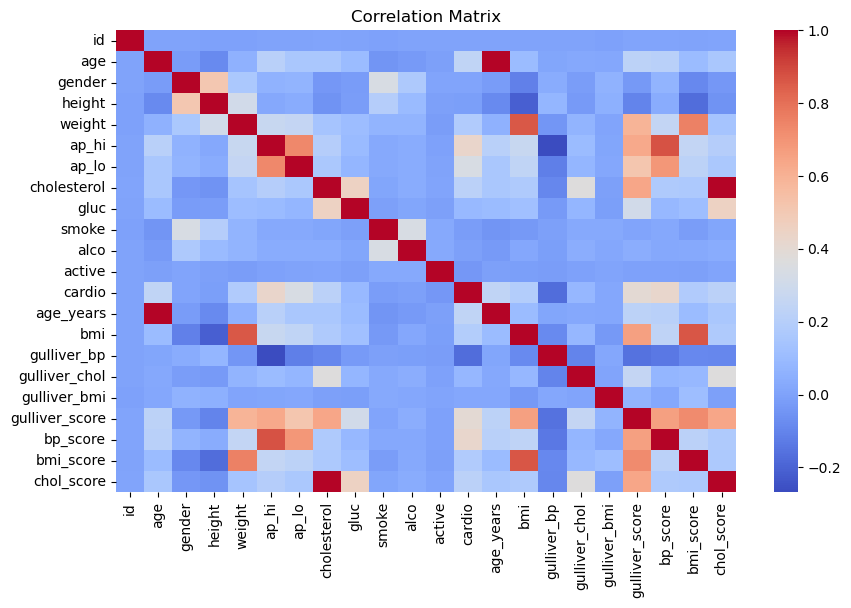

In [37]:
# Correlation heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

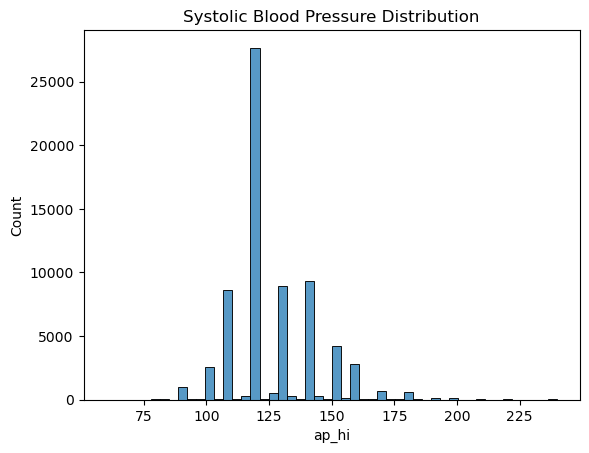

In [38]:
# Distribution of blood pressure
sns.histplot(df['ap_hi'], bins=50)
plt.title("Systolic Blood Pressure Distribution")
plt.show()

## Gulliver Score Definition

The Gulliver Score is defined as the sum of subclinical risk indicators:
- Blood pressure (borderline hypertension)
- Cholesterol levels
- BMI

Each variable is discretised into risk categories and aggregated.

In [39]:
# Define borderline conditions
def bp_score(x):
    if x < 120:
        return 0
    elif 120 <= x < 140:
        return 1
    else:
        return 2

df['bp_score'] = df['ap_hi'].apply(bp_score)

def bmi_score(x):
    if x < 25:
        return 0
    elif 25 <= x < 30:
        return 1
    else:
        return 2

df['bmi_score'] = df['bmi'].apply(bmi_score)

def chol_score(x):
    if x == 1:
        return 0
    elif x == 2:
        return 1
    else:
        return 2

df['chol_score'] = df['cholesterol'].apply(chol_score)

# Composite score
df['gulliver_score'] = df[['bp_score', 'bmi_score', 'chol_score']].sum(axis=1)


In [40]:
df.groupby('gulliver_score')['cardio'].mean()

gulliver_score
0    0.165006
1    0.301429
2    0.445562
3    0.605568
4    0.775340
5    0.833131
6    0.827139
Name: cardio, dtype: float64

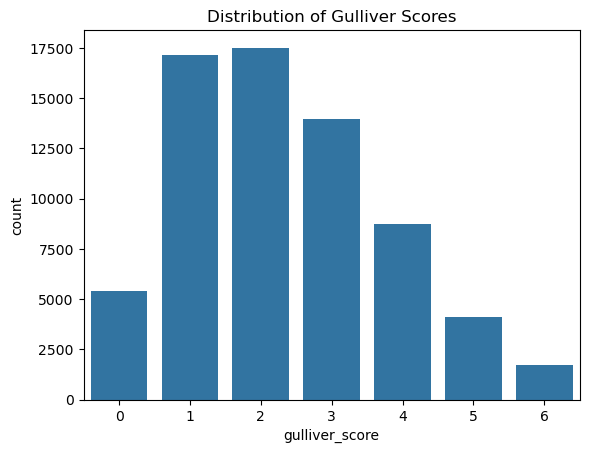

In [51]:
sns.countplot(x='gulliver_score', data=df)
plt.title("Distribution of Gulliver Scores")
plt.show()

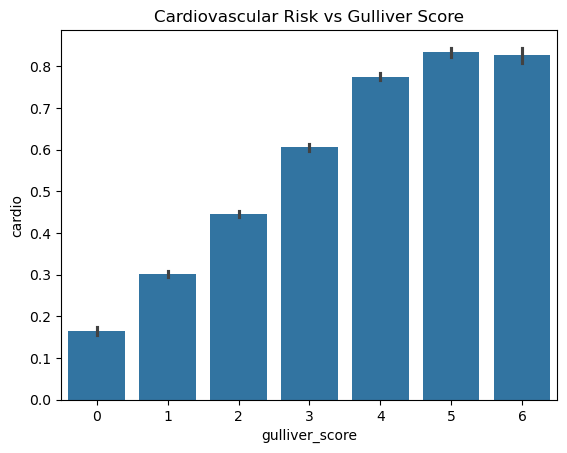

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='gulliver_score', y='cardio', data=df)
plt.title("Cardiovascular Risk vs Gulliver Score")
plt.show()

Mean cardiovascular risk increases progressively with higher Gulliver scores, supporting a cumulative risk model. While individual factors such as cholesterol show moderate associations with disease, their combined effect—captured by the Gulliver score—produces a clearer and more consistent risk gradient.

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scip

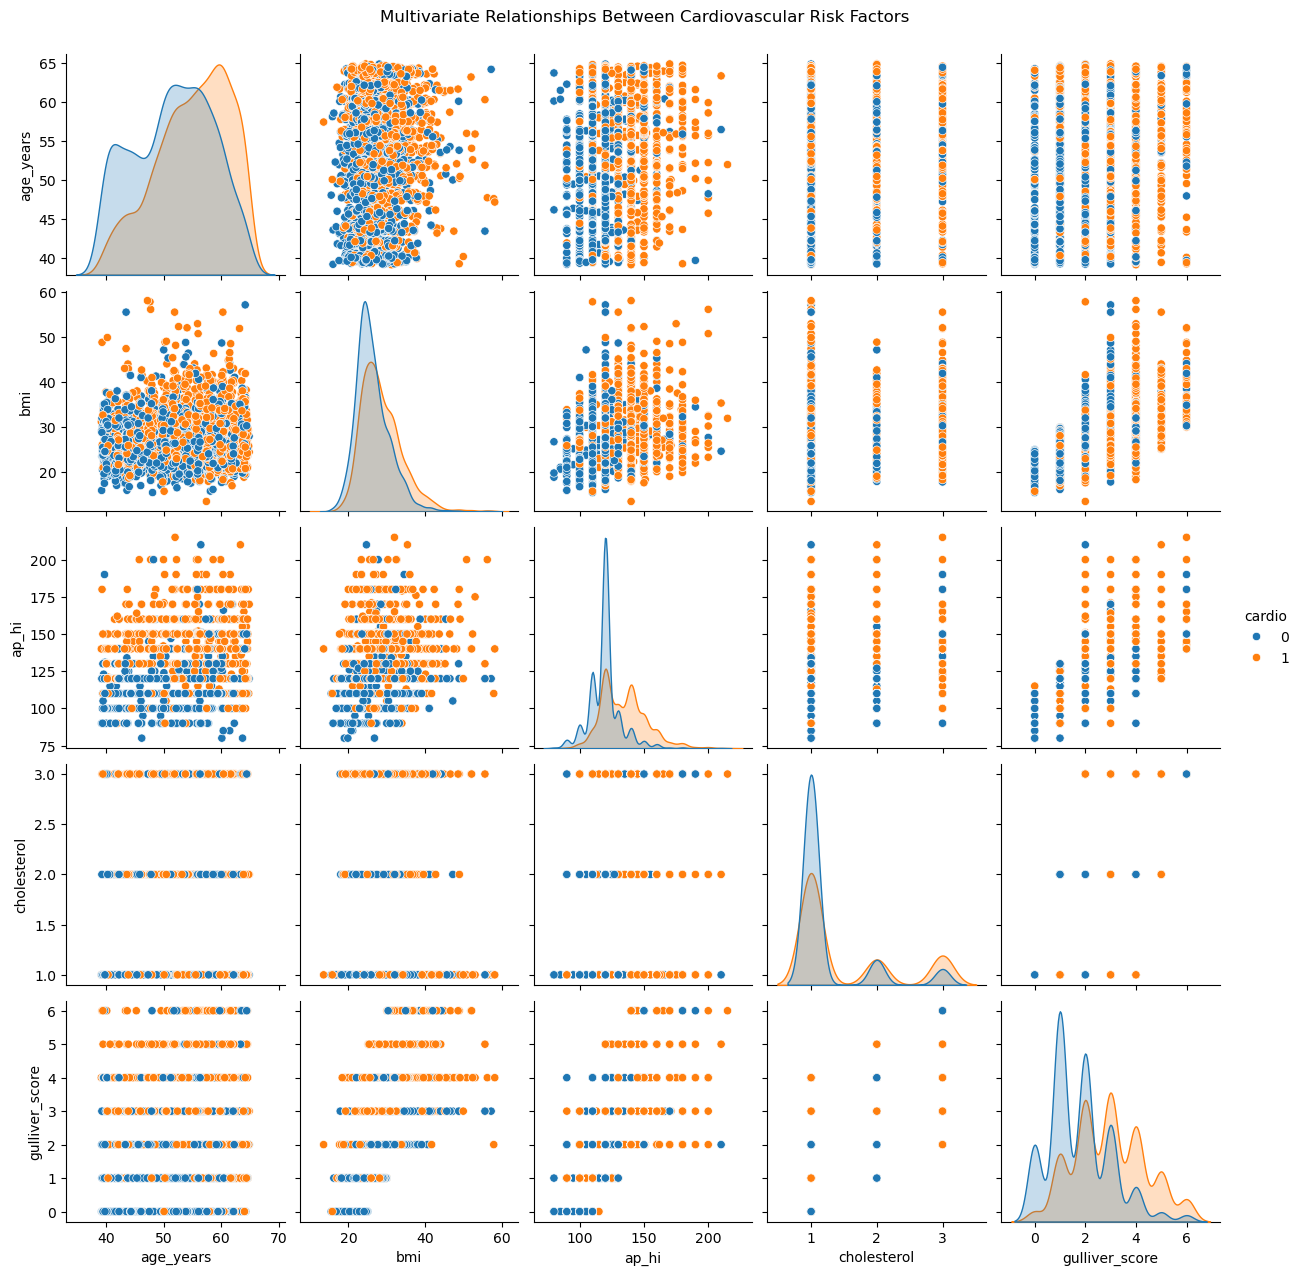

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sample = df.sample(4000, random_state=42)

sns.pairplot(
    df_sample,
    vars=['age_years', 'bmi', 'ap_hi', 'cholesterol', 'gulliver_score'],
    hue='cardio',
    kind='scatter',
    diag_kind='kde'
)

plt.suptitle("Multivariate Relationships Between Cardiovascular Risk Factors", y=1.02)
plt.show()

Pairwise scatter and kernel density plots illustrate the joint distribution of age, BMI, systolic blood pressure (ap_hi), cholesterol, and the composite Gulliver score, stratified by cardiovascular disease status. Individuals with cardiovascular disease (orange) exhibit a consistent shift toward higher values across multiple variables, particularly age, BMI, and systolic blood pressure. The Gulliver score shows progressive separation between groups, supporting its role as an aggregate measure of cumulative subclinical risk.

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scip

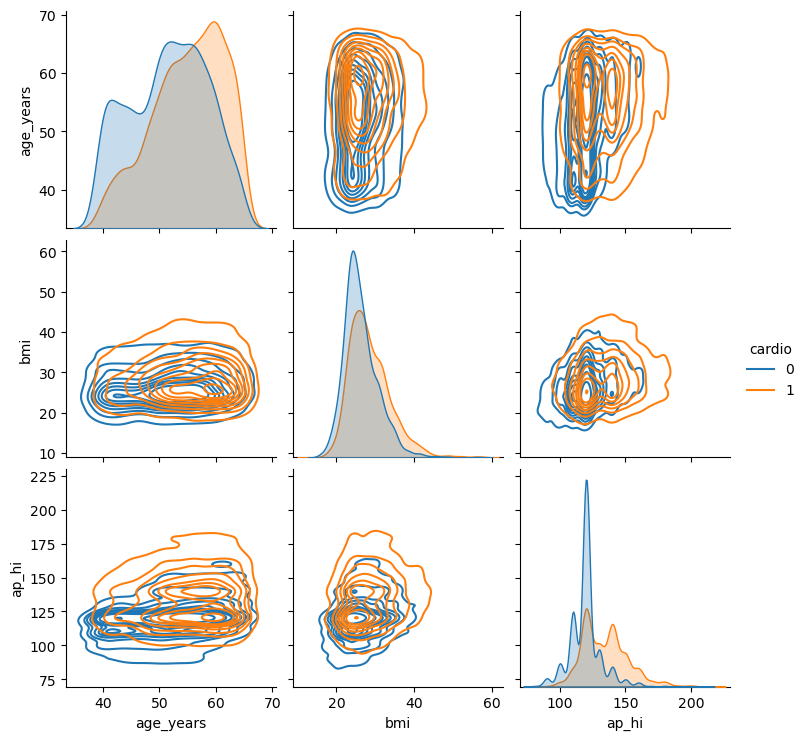

In [80]:
sns.pairplot(
    df_sample,
    vars=['age_years', 'bmi', 'ap_hi'],
    hue='cardio',
    kind='kde'
)

The KDE plots demonstrate that cardiovascular disease is associated with a joint shift across multiple mildly elevated risk factors, rather than extreme values in a single variable.
These findings visually support the conceptual framework of Gulliver syndrome, where multiple subclinical abnormalities collectively increase cardiovascular risk, even when individual features remain within near-normal ranges.
While individual variables exhibit overlap between classes, their combined distributions reveal clearer separation, supporting a cumulative risk model consistent with the Gulliver syndrome framework.

In [54]:
df['risk_group'] = pd.cut(df['gulliver_score'],
                         bins=[-1,1,3,6],
                         labels=['Low','Moderate','High'])

In [55]:
Risk_group_GS = df.groupby('risk_group', observed=False)['cardio'].mean()
print(Risk_group_GS)

risk_group
Low         0.268670
Moderate    0.516583
High        0.797692
Name: cardio, dtype: float64


In [56]:
# Risk vs score
risk_by_score = df.groupby('gulliver_score')['cardio'].mean()
print(risk_by_score)

gulliver_score
0    0.165006
1    0.301429
2    0.445562
3    0.605568
4    0.775340
5    0.833131
6    0.827139
Name: cardio, dtype: float64


In [57]:
conn = sqlite3.connect(":memory:")
df.to_sql("patients", conn, index=False)

query = """
SELECT gulliver_score, COUNT(*) as count, AVG(cardio) as risk
FROM patients
GROUP BY gulliver_score
"""

sql_result = pd.read_sql(query, conn)
sql_result

,gulliver_score,count,risk
0,0,5418,0.165006
1,1,17145,0.301429
2,2,17506,0.445562
3,3,13972,0.605568
4,4,8751,0.775340
5,5,4111,0.833131
6,6,1695,0.827139


In [58]:
features = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'gulliver_score']
X = df[features]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.698469387755102


In [59]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4956 1973]
 [2164 4627]]
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6929
           1       0.70      0.68      0.69      6791

    accuracy                           0.70     13720
   macro avg       0.70      0.70      0.70     13720
weighted avg       0.70      0.70      0.70     13720



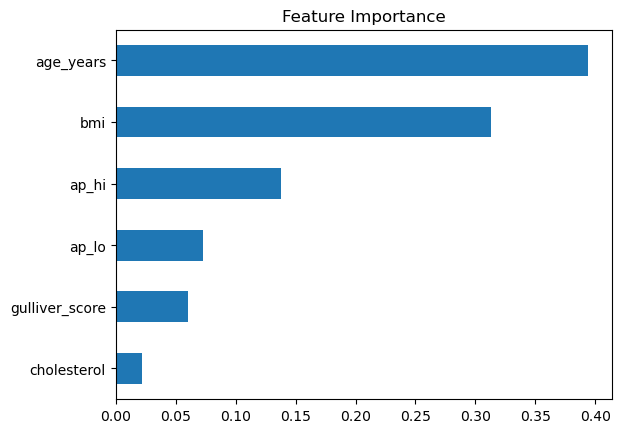

In [60]:
# Feature importance
importances = model.feature_importances_

feat_importance = pd.Series(importances, index=features)
feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [61]:
import numpy as np

print("NaNs:", np.isnan(X).sum())
print("Infs:", np.isinf(X).sum())

print(df[['ap_hi','ap_lo','bmi']].describe())

NaNs: age_years         0
bmi               0
ap_hi             0
ap_lo             0
cholesterol       0
gulliver_score    0
dtype: int64
Infs: age_years         0
bmi               0
ap_hi             0
ap_lo             0
cholesterol       0
gulliver_score    0
dtype: int64
              ap_hi         ap_lo           bmi
count  68598.000000  68598.000000  68598.000000
mean     126.663970     81.297574     27.447704
std       16.672455      9.415502      5.210541
min       60.000000     40.000000     10.726644
25%      120.000000     80.000000     23.875115
50%      120.000000     80.000000     26.346494
75%      140.000000     90.000000     30.116213
max      240.000000    140.000000     59.523810


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7262390670553935


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [63]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Random Forest Accuracy: 0.698469387755102
Logistic Regression Accuracy: 0.7262390670553935


In [64]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob_rf = model.predict_proba(X_test)[:,1]
y_prob_log = log_model.predict_proba(X_test)[:,1]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [65]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

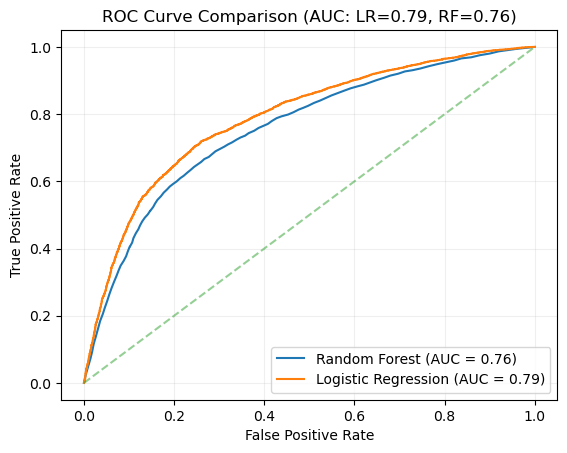

In [74]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', alpha=0.5) # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.2)
plt.title("ROC Curve Comparison (AUC: LR=0.79, RF=0.76)")
plt.legend(loc='lower right', frameon=True)

plt.show()

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

cv_scores_lr = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/s

In [76]:
cv_scores_rf = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

print("Random Forest CV AUC:", cv_scores_rf)
print("Mean CV AUC:", cv_scores_rf.mean())

Random Forest CV AUC: [0.74475195 0.75335223 0.75054438 0.75769682 0.746385  ]
Mean CV AUC: 0.7505460760669884


## Cross-Validation Results

Cross-validation demonstrated consistent model performance across folds, indicating robustness and low variance.

Logistic Regression achieved a higher mean AUC (0.79) compared to Random Forest (0.75), suggesting that the relationship between cumulative risk factors and cardiovascular disease is predominantly linear.

Cross-validation confirmed that model performance is stable across folds, indicating that results are not driven by a specific train-test split.

This supports the hypothesis underlying the Gulliver syndrome framework, where multiple subclinical abnormalities contribute additively to disease risk.

## Key Findings

- Cardiovascular risk increases monotonically with the number of subclinical abnormalities
- Individuals with ≥4 risk factors show >75% disease probability, indicating strong cumulative effects
- Logistic Regression (AUC = 0.79) outperformed Random Forest (AUC = 0.76), suggesting largely linear risk structure
- Age and BMI emerged as dominant predictors, with blood pressure contributing secondary but consistent effects

## Conclusion

This project demonstrated that cumulative subclinical risk factors are strongly associated with cardiovascular disease, with a clear monotonic increase in risk as the Gulliver score rises. 

While the composite score effectively captures aggregated risk patterns, machine learning results showed that individual features such as age and BMI remain more predictive, highlighting the importance of combining domain-driven feature engineering with data-driven modelling approaches.

The superior performance of Logistic Regression suggests that cardiovascular risk in this dataset follows largely additive and linear relationships, supporting the use of interpretable models for early risk stratification.

These findings support a shift from threshold-based diagnosis toward cumulative risk assessment in preventive cardiology.

Overall, this work illustrates both the value and limitations of threshold-based clinical scoring systems, and suggests that integrating continuous variables and modelling interactions could further improve predictive performance.
